### `Installing relevant libraries`

In [1]:
# installing appropriate libraries
import pandas as pd
import os
import sys
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import gensim
import spacy

from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from gensim.utils import simple_preprocess

### `Accessing data via hugging face`

In [2]:
# Define file path
splits = {'train': 'data/train-00000-of-00001.parquet', 'test': 'data/test-00000-of-00001.parquet'}

# load train data from huggingface into dataframe
df = pd.read_parquet("hf://datasets/wangrongsheng/ag_news/" + splits["train"])

# load test data into from huggingface dataframe
df2 = pd.read_parquet("hf://datasets/wangrongsheng/ag_news/" + splits["test"])

### `Store data in csv files`

In [3]:
# store train data in csv files
df.to_csv("ag_news_train.csv", index=False)

# load train data
train_df = pd.read_csv("ag_news_train.csv")

In [4]:
# store test data in csv files
df2.to_csv("ag_news_test.csv", index=False)

# load test data
test_df = pd.read_csv("ag_news_test.csv")

In [5]:
# Map numeric labels to human‑readable class names
label_names = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}

# Create a new column in the training set with readable labels
train_df['label_name'] = train_df['label'].map(label_names)
test_df['label_name']  = test_df['label'].map(label_names)

# Print the shapes of both datasets to confirm the new column was added
print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)
print("\nFirst 5 rows:")
train_df.head()

Train shape: (120000, 3)
Test shape:  (7600, 3)

First 5 rows:


,text,label,label_name
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


In [6]:
test_df.head()

,text,label,label_name
0,Fears for T N pension after talks Unions repre...,2,Business
1,The Race is On: Second Private Team Sets Launc...,3,Sci/Tech
2,Ky. Company Wins Grant to Study Peptides (AP) ...,3,Sci/Tech
3,Prediction Unit Helps Forecast Wildfires (AP) ...,3,Sci/Tech
4,Calif. Aims to Limit Farm-Related Smog (AP) AP...,3,Sci/Tech


### `Class Distribution`

Label Distribution (Train)
            Count  Proportion (%)
label_name                       
Business    30000            25.0
Sci/Tech    30000            25.0
Sports      30000            25.0
World       30000            25.0


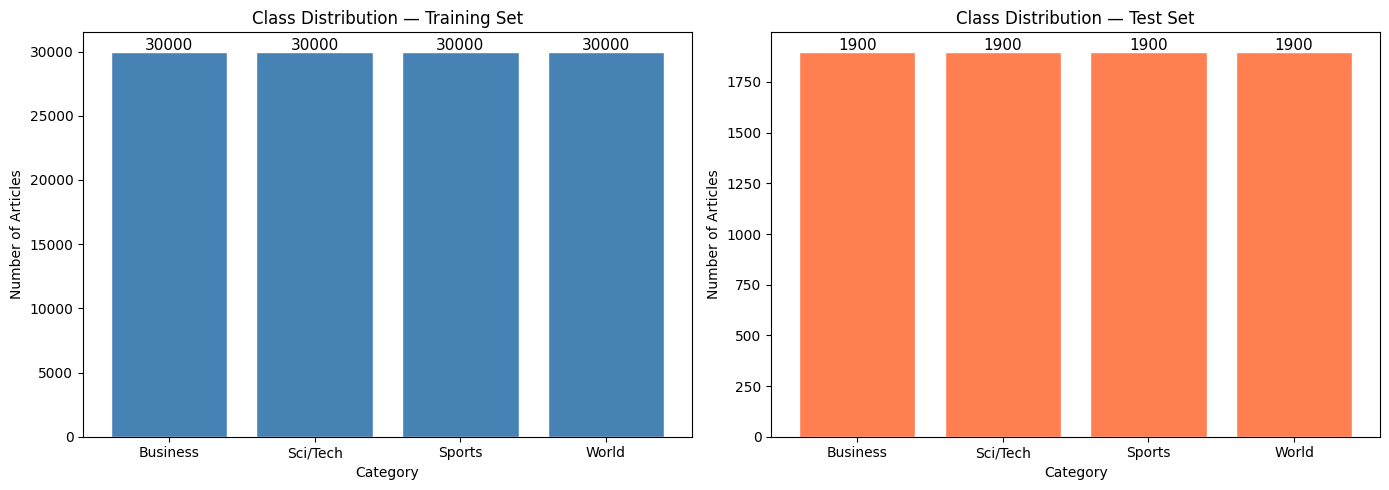


Conclusion: Dataset is perfectly balanced.
Each class has 30000 training samples and 1900 test samples.


In [7]:
# Count and proportion for classes
label_counts = train_df['label_name'].value_counts()
label_props  = train_df['label_name'].value_counts(normalize=True) * 100

label_summary = pd.DataFrame({
    'Count': label_counts,
    'Proportion (%)': label_props.round(2)
})
print("Label Distribution (Train)")
print(label_summary)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart for train set
axes[0].bar(label_counts.index, label_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Class Distribution — Training Set')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Articles')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontsize=11)

# Bar chart for test set
test_counts = test_df['label_name'].value_counts()
axes[1].bar(test_counts.index, test_counts.values, color='coral', edgecolor='white')
axes[1].set_title('Class Distribution — Test Set')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Number of Articles')
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

print("\nConclusion: Dataset is perfectly balanced.")
print(f"Each class has {label_counts.min()} training samples and {test_counts.min()} test samples.")

### `Text Analysis`


 Text Length by Class (Train)
              count   mean    std   min   25%   50%   75%    max
label_name                                                      
Business    30000.0  37.54   8.12   8.0  32.0  37.0  42.0  134.0
Sci/Tech    30000.0  37.19  12.42   8.0  30.0  36.0  42.0  177.0
Sports      30000.0  37.77   8.87   8.0  32.0  37.0  42.0  151.0
World       30000.0  38.88  10.32  11.0  33.0  39.0  44.0  145.0


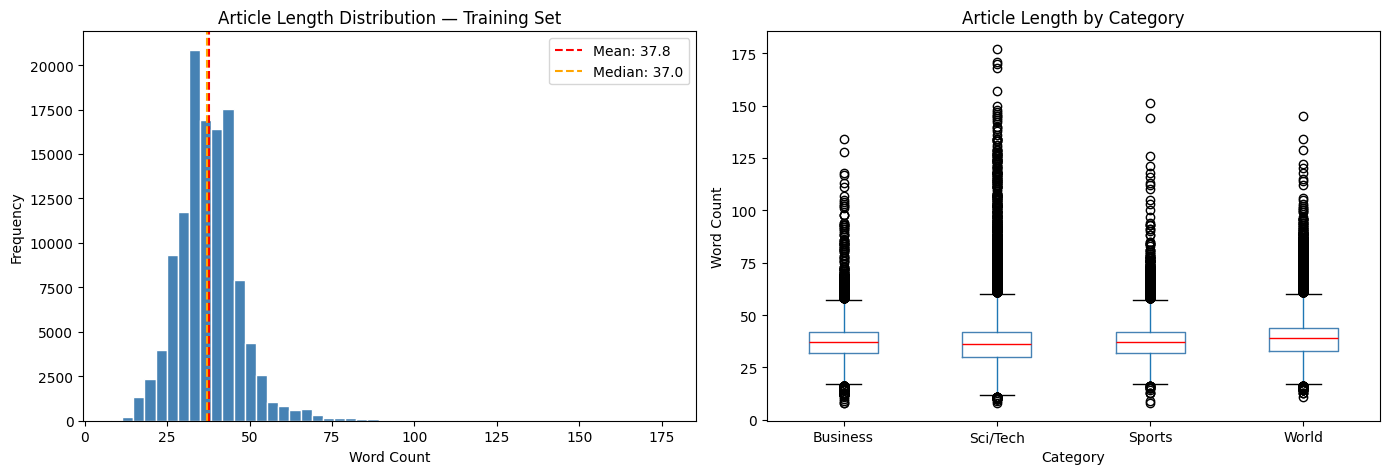

In [8]:
# Compute word counts
train_df['word_count'] = train_df['text'].str.split().str.len()
test_df['word_count']  = test_df['text'].str.split().str.len()

# Per class statistics
print("\n Text Length by Class (Train)")
print(train_df.groupby('label_name')['word_count'].describe().round(2))

# Overall histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df['word_count'], bins=50,
             color='steelblue', edgecolor='white')
axes[0].set_title('Article Length Distribution — Training Set')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(train_df['word_count'].mean(),
                color='red', linestyle='--',
                label=f"Mean: {train_df['word_count'].mean():.1f}")
axes[0].axvline(train_df['word_count'].median(),
                color='orange', linestyle='--',
                label=f"Median: {train_df['word_count'].median():.1f}")
axes[0].legend()

# Length by class boxplot
train_df.boxplot(column='word_count', by='label_name',
                 ax=axes[1], grid=False,
                 boxprops=dict(color='steelblue'),
                 medianprops=dict(color='red'))
axes[1].set_title('Article Length by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Word Count')
plt.suptitle('')

plt.tight_layout()
plt.savefig('length_distribution.png', dpi=150)
plt.show()

### Checking missing values 

In [10]:
# Missing values
missing_train = train_df['text'].isnull().sum()
missing_test  = test_df['text'].isnull().sum()
print(f"Missing values — Train: {missing_train} | Test: {missing_test}")

# Empty strings
empty_train = (train_df['text'].str.strip() == '').sum()
empty_test  = (test_df['text'].str.strip() == '').sum()
print(f"Empty strings  — Train: {empty_train} | Test: {empty_test}")

# Word count (create column first)
train_df['word_count'] = train_df['text'].str.split().str.len()
test_df['word_count']  = test_df['text'].str.split().str.len()

# Near empty (less than 5 words)
nearly_empty_train = (train_df['word_count'] < 5).sum()
nearly_empty_test  = (test_df['word_count'] < 5).sum()
print(f"Almost empty (<5 words) — Train: {nearly_empty_train} | Test: {nearly_empty_test}")

# Duplicates
dup_train = train_df['text'].duplicated().sum()
dup_test  = test_df['text'].duplicated().sum()
print(f"Duplicate texts — Train: {dup_train} | Test: {dup_test}")

# Summary
if missing_train == 0 and empty_train == 0 and dup_train == 0:
    print("\nTraining set is clean: no missing values, empty strings or duplicates detected.")
if missing_test == 0 and empty_test == 0 and dup_test == 0:
    print("Test set is clean: no missing values, empty strings or duplicates detected.")

Missing values — Train: 0 | Test: 0
Empty strings  — Train: 0 | Test: 0
Almost empty (<5 words) — Train: 0 | Test: 0
Duplicate texts — Train: 0 | Test: 0

Training set is clean: no missing values, empty strings or duplicates detected.
Test set is clean: no missing values, empty strings or duplicates detected.


### `Data Cleaning`

In [11]:
# Remove Punctuation
train_df["text"] = train_df["text"].astype(str).apply(lambda x : re.sub('[,.?!]', '', x))
train_df["text"] = train_df["text"].str.lower()

test_df["text"] = test_df["text"].astype(str).apply(lambda x : re.sub('[,.?!]', '', x))
test_df["text"] = test_df["text"].str.lower()

### `Text Preprocessing`

In [12]:
import gensim
import spacy
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS

nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])
my_stop_words = STOPWORDS

# break down sentences into words
def sent_to_words(sentences):
    for sentence in sentences:
        yield simple_preprocess(sentence, deacc=False)

# remove stopwords
def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) 
             if word not in my_stop_words] for doc in texts]

# turns words into base form, keep nouns, adjectives, verbs, or adverbs
def lemmatization(texts, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV']):
    texts_out = []
    for doc in nlp.pipe([" ".join(sent) for sent in texts], batch_size=500, n_process=-1):
        texts_out.append([token.lemma_ for token in doc 
                          if token.pos_ in allowed_postags])
    return texts_out

# build bigram and trigrams
def build_ngram_models(data_words):
    """Fit bigram and trigram models on training data only."""
    bigram = gensim.models.phrases.Phrases(data_words, min_count=5, threshold=100)
    trigram = gensim.models.phrases.Phrases(bigram[data_words], threshold=100)
    bigram_mod = gensim.models.phrases.Phraser(bigram)
    trigram_mod = gensim.models.phrases.Phraser(trigram)
    return bigram_mod, trigram_mod

def preprocess_pipeline(df, column, bigram_mod=None, trigram_mod=None, fit=False):
    """
    Full NLP preprocessing pipeline.
    
    Args:
        df         : input dataframe
        column     : text column name
        bigram_mod : pre-fitted bigram Phraser (used when fit=False)
        trigram_mod: pre-fitted trigram Phraser (used when fit=False)
        fit        : if True, fits ngram models on this data (use for train only)
    
    Returns:
        data_lemmatized, bigram_mod, trigram_mod
    """
    # Tokenize
    data = df[column].to_list()
    data_words = list(sent_to_words(data))
    
    # Remove stopwords
    data_words_no_stops = remove_stopwords(data_words)
    
    # Fit ngram models on train, reuse on test
    if fit:
        bigram_mod, trigram_mod = build_ngram_models(data_words_no_stops)
    
    # Apply ngrams
    data_words_bigrams = [bigram_mod[doc] for doc in data_words_no_stops]
    data_words_trigrams = [trigram_mod[bigram_mod[doc]] for doc in data_words_bigrams]
    
    # Lemmatize
    data_lemmatized = lemmatization(data_words_trigrams)
    
    return data_lemmatized, bigram_mod, trigram_mod

In [29]:
def getWordCloud(tokens_list):
    """
    Generates a WordCloud object
    from a list of tokenised texts.

        Args:
            tokens_list (list of str):
        A list where each element is a
        string representing preprocessed 
        text tokens.
        Returns: wordcloud

    """
    text = ' '.join(tokens_list)
    if not text.strip():
        return None

    wc = WordCloud(max_font_size=200,
        background_color='white',
        width=2400,
        height=2000
    ).generate(text)
    return wc

In [30]:
# Call pipeline on train
train_lemmatized, bigram_mod, trigram_mod = preprocess_pipeline(
    train_df, 'text', fit=True
)

# Attach lemmatized results back to df
train_df['lemmatized'] = train_lemmatized

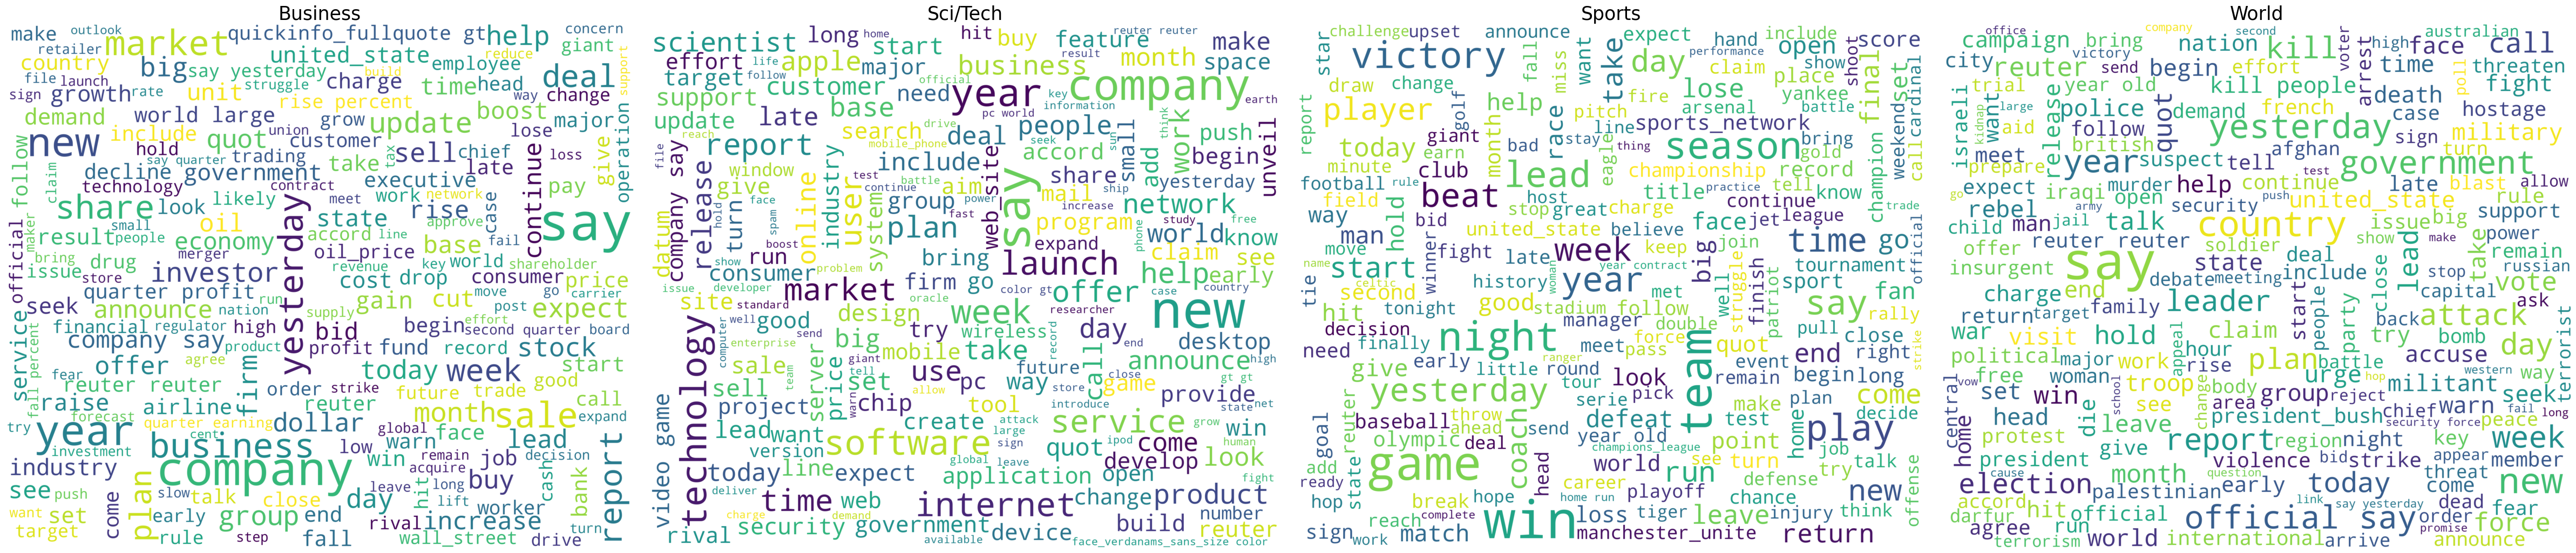

In [31]:
labels = sorted(train_df['label_name'].unique())
n_labels = len(labels)

fig, axes = plt.subplots(
    1, n_labels,
    figsize=(12 * n_labels, 10)
)

# Handle case of one class only
if n_labels == 1:
    axes = [axes]

for ax, label in zip(axes, labels):
    class_texts = train_df[
        train_df['label_name'] == label
    ]['lemmatized']

    strings = [' '.join(tokens) for tokens in class_texts]
    wc = getWordCloud(strings)

    if wc is not None:
        ax.imshow(wc, interpolation='bilinear')
    ax.set_title(label, fontsize=25)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Multinomial Naives Bayes

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score,recall_score,f1_score
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

# Split train_df into train and val
train_split, val_split = train_test_split(
    train_df,
    test_size=0.1, # validation size
    random_state=42,
    stratify=train_df['label']
)

# Preprocess
train_lemmatized, bigram_mod, trigram_mod = preprocess_pipeline(train_split, 'text', fit=True)
val_lemmatized, _, _ = preprocess_pipeline(val_split, 'text', bigram_mod=bigram_mod, trigram_mod=trigram_mod)
test_lemmatized, _, _ = preprocess_pipeline(test_df, 'text', bigram_mod=bigram_mod, trigram_mod=trigram_mod)

# Convert to strings 
X_train = [' '.join(l) for l in train_lemmatized]
X_val   = [' '.join(l) for l in val_lemmatized]
X_test  = [' '.join(l) for l in test_lemmatized]

# Labels 
y_train = train_split['label'].to_numpy()
y_val   = val_split['label'].to_numpy()
y_test  = test_df['label'].to_numpy()

# TF-IDF Pipeline — fit on train only 
pipeline = Pipeline([
    ("vect", CountVectorizer()),
    ("tfidf", TfidfTransformer()),
])

X_train_tfidf = pipeline.fit_transform(X_train)
X_val_tfidf   = pipeline.transform(X_val)
X_test_tfidf  = pipeline.transform(X_test)

# Multinomial Naive Bayes 
mnb = MultinomialNB()
mnb.fit(X_train_tfidf, y_train)

y_pred_val  = mnb.predict(X_val_tfidf)

# Convert label_names dict into a list ordered by label ID
target_names = [label_names[i] for i in sorted(label_names.keys())]

print("\nValidation for base Multinomial Naives Bayes Model")
print(classification_report(y_val, y_pred_val, target_names=target_names))

# Overall accuracy
val_accuracy = accuracy_score(y_val, y_pred_val) * 100
val_precision = precision_score(y_val, y_pred_val, average='weighted') * 100
val_recall    = recall_score(y_val, y_pred_val, average='weighted') * 100
val_f1        = f1_score(y_val, y_pred_val, average='weighted') * 100

print(f"Overall Validation Accuracy: {val_accuracy:.0f}%")
print(f"Overall Validation Precision: {val_precision:.0f}%")
print(f"Overall Validation Recall: {val_recall:.0f}%")
print(f"Overall Validation F1-score: {val_f1:.0f}%")


Validation for base Multinomial Naives Bayes Model
              precision    recall  f1-score   support

       World       0.88      0.87      0.88      3000
      Sports       0.94      0.95      0.94      3000
    Business       0.85      0.86      0.85      3000
    Sci/Tech       0.86      0.85      0.85      3000

    accuracy                           0.88     12000
   macro avg       0.88      0.88      0.88     12000
weighted avg       0.88      0.88      0.88     12000

Overall Validation Accuracy: 88%
Overall Validation Precision: 88%
Overall Validation Recall: 88%
Overall Validation F1-score: 88%


### `Hyperparameter Tuning Using GridSearchCV`

In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, precision_score,recall_score,f1_score

# Define base pipeline for tuning
pipe = Pipeline([
    ("vect", CountVectorizer()),
    ("tfidf", TfidfTransformer()),
    ("clf", MultinomialNB())
])

# Hyperparameter grid
param_grid = {
    "vect__ngram_range":   [(1,1), (1,2)],
    "vect__max_features":  [20000, 50000],
    "tfidf__sublinear_tf": [True, False],
    "clf__alpha":          [0.1, 0.5, 1.0],
}

# Grid search
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best hyperparameters:")
print(grid.best_params_)

# rebuild final model using best parameters
best_params = grid.best_params_

mnb2 = Pipeline([
    ("vect", CountVectorizer(
        ngram_range=best_params["vect__ngram_range"],
        max_features=best_params["vect__max_features"]
    )),
    ("tfidf", TfidfTransformer(
        sublinear_tf=best_params["tfidf__sublinear_tf"]
    )),
    ("clf", MultinomialNB(
        alpha=best_params["clf__alpha"]
    ))
])

# retrain final model
mnb2.fit(X_train, y_train)

# validation performance
y_pred_val = mnb2.predict(X_val)
print("\nValidation Performance (Final Model)")

print(classification_report(y_val, y_pred_val, target_names=target_names))
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred_val) * 100:.0f}%")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best hyperparameters:
{'clf__alpha': 0.1, 'tfidf__sublinear_tf': True, 'vect__max_features': 50000, 'vect__ngram_range': (1, 1)}

Validation Performance (Final Model)
              precision    recall  f1-score   support

       World       0.89      0.88      0.88      3000
      Sports       0.95      0.96      0.95      3000
    Business       0.86      0.85      0.86      3000
    Sci/Tech       0.86      0.86      0.86      3000

    accuracy                           0.89     12000
   macro avg       0.89      0.89      0.89     12000
weighted avg       0.89      0.89      0.89     12000

Validation Accuracy: 89%


### `Final Results for Multinomial Bayes model`

In [37]:
# Test
y_pred_test_nb = mnb2.predict(X_test)
print("\nTest Performance (Final Model)")
print(classification_report(y_test, y_pred_test_nb, target_names=target_names))

print(f"Overall Test Accuracy:  {accuracy_score(y_test, y_pred_test_nb) * 100:.0f}%")
print(f"Overall Test Precision: {precision_score(y_test, y_pred_test_nb, average='weighted') * 100:.0f}%")
print(f"Overall Test Recall:    {recall_score(y_test, y_pred_test_nb, average='weighted') * 100:.0f}%")
print(f"Overall Test F1-score:  {f1_score(y_test, y_pred_test_nb, average='weighted') * 100:.0f}%")


Test Performance (Final Model)
              precision    recall  f1-score   support

       World       0.89      0.87      0.88      1900
      Sports       0.95      0.95      0.95      1900
    Business       0.84      0.83      0.84      1900
    Sci/Tech       0.85      0.86      0.85      1900

    accuracy                           0.88      7600
   macro avg       0.88      0.88      0.88      7600
weighted avg       0.88      0.88      0.88      7600

Overall Test Accuracy:  88%
Overall Test Precision: 88%
Overall Test Recall:    88%
Overall Test F1-score:  88%


### `Confusion Matrix for Multinomian Naives Bayes`

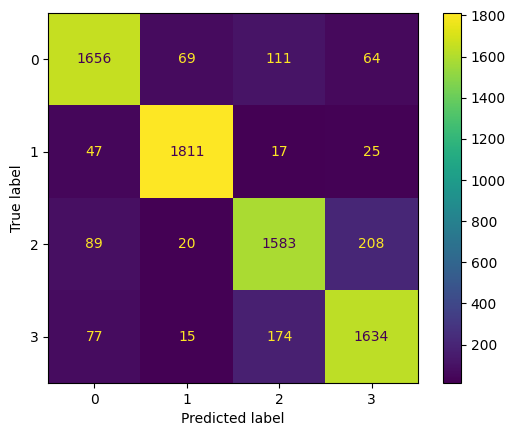

In [38]:
# confusion matrix for Naives Bayes
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_test_nb)
ConfusionMatrixDisplay(cm).plot()

### `Support Vector Machine`

In [39]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

# Baseline SVM
svm = Pipeline([
    ("vect", CountVectorizer()),
    ("tfidf", TfidfTransformer()),
    ("clf", LinearSVC(max_iter=3000, random_state=42))
])
# train model
svm.fit(X_train, y_train)

# predit model on validation set
y_pred_val = svm.predict(X_val)
print("Baseline SVM Validation ")
print(classification_report(y_val, y_pred_val, target_names=target_names))
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred_val) * 100:.0f}%")

Baseline SVM Validation 
              precision    recall  f1-score   support

       World       0.91      0.87      0.89      3000
      Sports       0.93      0.97      0.95      3000
    Business       0.85      0.86      0.86      3000
    Sci/Tech       0.87      0.86      0.87      3000

    accuracy                           0.89     12000
   macro avg       0.89      0.89      0.89     12000
weighted avg       0.89      0.89      0.89     12000

Validation Accuracy: 89%


### `Hyperparameter tuning for Linear SVC`

In [40]:
from sklearn.model_selection import GridSearchCV

# Parameter Grid
param_grid = [
    # squared_hinge, works with dual=False
    {
        "vect__ngram_range": [(1, 1), (1, 2)],
        "tfidf__sublinear_tf": [True, False],
        "clf__C": [0.1, 1, 10],
        "clf__loss": ["squared_hinge"],
        "clf__dual": [False],
    },
    # hinge requires dual=True
    {
        "vect__ngram_range": [(1, 1), (1, 2)],
        "tfidf__sublinear_tf": [True, False],
        "clf__C": [0.1, 1, 10],
        "clf__loss": ["hinge"],
        "clf__dual": [True],
    },
]

# Base Pipeline for Tuning
tune_pipeline = Pipeline([
    ("vect", CountVectorizer(max_features=30000)),
    ("tfidf", TfidfTransformer()),
    ("clf", LinearSVC(
        max_iter=50000,
        random_state=42
    ))
])

# Grid Search
grid = GridSearchCV(
    estimator=tune_pipeline,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring="f1_weighted"
)

# train model on selected parameters
grid.fit(X_train, y_train)

# Best Parameters
print("\nBest hyperparameters:")
print(grid.best_params_)

best = grid.best_params_

# Final Tuned Model
svm2 = Pipeline([
    ("vect", CountVectorizer(
        max_features=20000,            
        min_df=2,
        ngram_range=best["vect__ngram_range"]
    )),
    ("tfidf", TfidfTransformer(
        sublinear_tf=best["tfidf__sublinear_tf"]
    )),
    ("clf", LinearSVC(
        C=best["clf__C"],
        loss=best["clf__loss"],
        dual=best["clf__dual"],
        max_iter=50000,
        random_state=42
    ))
])

# Train Final Model
svm2.fit(X_train, y_train)


# Validation Evaluation
y_pred_val = svm2.predict(X_val)

print("\nTuned SVM Validation Results")
print(
    classification_report(
        y_val,
        y_pred_val,
        target_names=target_namesv
    )
)

accuracy = accuracy_score(y_val, y_pred_val)
print(f"Validation Accuracy: {accuracy * 100:.0f}%")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best hyperparameters:
{'clf__C': 1, 'clf__dual': True, 'clf__loss': 'hinge', 'tfidf__sublinear_tf': True, 'vect__ngram_range': (1, 1)}

Tuned SVM Validation Results
              precision    recall  f1-score   support

       World       0.92      0.87      0.89      3000
      Sports       0.93      0.97      0.95      3000
    Business       0.86      0.87      0.87      3000
    Sci/Tech       0.88      0.87      0.87      3000

    accuracy                           0.90     12000
   macro avg       0.90      0.90      0.90     12000
weighted avg       0.90      0.90      0.90     12000

Validation Accuracy: 90%


### `Final Results for Linear SVC`

In [41]:
# evaluating model on test set
y_pred_test_svc = svm2.predict(X_test)

print("\nTuned SVM Test")
print(classification_report(y_test, y_pred_test_svc, target_names=target_names))
print(f"Final Accuracy for SVC:  {accuracy_score(y_test, y_pred_test_svc) * 100:.0f}%")
print(f"Final Precision for SVC: {precision_score(y_test, y_pred_test_svc, average='weighted') * 100:.0f}%")
print(f"Final Recall for SVC:    {recall_score(y_test, y_pred_test_svc, average='weighted') * 100:.0f}%")
print(f"Final F1-score for SVC:  {f1_score(y_test, y_pred_test_svc, average='weighted') * 100:.0f}%")


Tuned SVM Test
              precision    recall  f1-score   support

       World       0.91      0.86      0.89      1900
      Sports       0.93      0.97      0.95      1900
    Business       0.85      0.85      0.85      1900
    Sci/Tech       0.86      0.87      0.87      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600

Final Accuracy for SVC:  89%
Final Precision for SVC: 89%
Final Recall for SVC:    89%
Final F1-score for SVC:  89%


### `Confusion Matrix for Linear SVC`

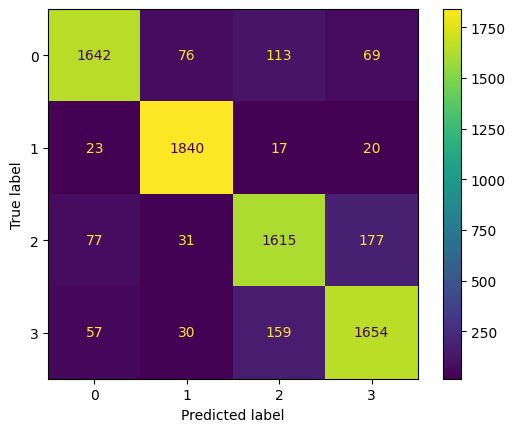

In [42]:
# confusion matrix for Linear SVC on test set
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_test_svc)
ConfusionMatrixDisplay(cm).plot()

In [43]:
import joblib

joblib.dump(svm, "svm_nlp_model.pkl")

['svm_nlp_model.pkl']

### `Convolutional Neural Networks`

In [45]:
# installing libraries
import numpy as np
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import re

### `Preprocessing and splitting data`

In [46]:
# Split train data
train_split, val_split = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42,
    stratify=train_df['label']
)

# Preprocessing for text cleaning
def preprocess_dl(df, column):
    texts = df[column].tolist()
    cleaned = []
    for text in texts:
        text = text.lower()
        text = re.sub(r'<.*?>', '', text)
        text = re.sub(r'[^a-z0-9\s]', '', text)
        text = text.strip()
        cleaned.append(text)
    return cleaned

X_train = preprocess_dl(train_split, 'text')
X_val   = preprocess_dl(val_split,   'text')
X_test  = preprocess_dl(test_df,     'text')

y_train = train_split['label'].to_numpy()
y_val   = val_split['label'].to_numpy()
y_test  = test_df['label'].to_numpy()

# Hyperparameters for tokenisation
vocab_size  = 20000 # maximum vocabulary size
maxlen      = 100 # sequence length
embed_dim   = 100 # word embeddings dimensionality
num_classes = 4 # output per class

#  train Word2Vec embedding 
train_tokens = [text.split() for text in X_train]

w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=embed_dim,
    window=5,
    min_count=2,
    workers=4,
    epochs=10
)

# Tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# convert text to pad sequences
X_train_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_train),
    maxlen=maxlen, padding='post', truncating='post'
)
X_val_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_val),
    maxlen=maxlen, padding='post', truncating='post'
)
X_test_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_test),
    maxlen=maxlen, padding='post', truncating='post'
)

### Unweighted Embedding matrix

In [47]:
# Embedding matrix
embedding_matrix = np.zeros((vocab_size, embed_dim))
for word, idx in tokenizer.word_index.items():
    if idx < vocab_size and word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word] 

### Weighted Embedding matrix

In [48]:
# TF-IDF weighted embedding matrix
tfidf = TfidfVectorizer(max_features=vocab_size)
tfidf.fit(X_train)

# building tf-idf weighted matrix on word2vec vectors
embedding_matrix_weighted = np.zeros((vocab_size, embed_dim))
tfidf_scores = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))

for word, idx in tokenizer.word_index.items():
    if idx < vocab_size and word in w2v_model.wv:
        vector = w2v_model.wv[word]
        weight = tfidf_scores.get(word, 1.0)
        embedding_matrix_weighted[idx] = vector * weight

### `Base CNN`

In [49]:
# Base CNN
inputs = keras.Input(shape=(maxlen,))
x = layers.Embedding(
    input_dim=vocab_size,
    output_dim=embed_dim,
    weights=[embedding_matrix],
    trainable=True
)(inputs)

# conv filters using kernel size 2 and 3
x1 = layers.Conv1D(128, 2, activation='relu', padding='same')(x)
x2 = layers.Conv1D(128, 3, activation='relu', padding='same')(x)

# Applying global max pooling to retain important feature
x1 = layers.GlobalMaxPooling1D()(x1)
x2 = layers.GlobalMaxPooling1D()(x2)

# pooled features, dropout and dense layer for class probabilities
x = layers.Concatenate()([x1, x2])
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

# create and display model architecture
cnn_base = keras.Model(inputs=inputs, outputs=outputs)
cnn_base.summary()

# compile model
cnn_base.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# train model
cnn_base_history = cnn_base.fit(
    X_train_pad, y_train,
    batch_size=64,
    epochs=10,
    validation_data=(X_val_pad, y_val),
    verbose=1
)

# predict model on evaluation set
y_pred_val = np.argmax(cnn_base.predict(X_val_pad), axis=1)
print("\nBase CNN Validation")
print(classification_report(y_val, y_pred_val, target_names=target_names))
print(f"Validation Accuracy:  {accuracy_score(y_val, y_pred_val) * 100:.0f}%")
print(f"Validation Precision: {precision_score(y_val, y_pred_val, average='weighted') * 100:.0f}%")
print(f"Validation Recall:    {recall_score(y_val, y_pred_val, average='weighted') * 100:.0f}%")
print(f"Validation F1-score:  {f1_score(y_val, y_pred_val, average='weighted') * 100:.0f}%")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 100)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 100, 100)          │       2,000,000 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 100, 128)          │          25,728 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_1 (Conv1D)             │ (None, 100, 128)          │          38,528 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d          │ (None, 128)               │               0 │ conv1d[0][0]               │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d_1        │ (None, 128)               │               0 │ conv1d_1[0][0]             │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 256)               │               0 │ global_max_pooling1d[0][0… │
│                               │                           │                 │ global_max_pooling1d_1[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 256)               │               0 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 64)                │          16,448 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 4)                 │             260 │ dense[0][0]                │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 2,080,964 (7.94 MB)

 Trainable params: 2,080,964 (7.94 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7955 - loss: 0.6273 - val_accuracy: 0.8969 - val_loss: 0.2966
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9011 - loss: 0.2830 - val_accuracy: 0.9159 - val_loss: 0.2468
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9190 - loss: 0.2295 - val_accuracy: 0.9201 - val_loss: 0.2344
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9319 - loss: 0.1944 - val_accuracy: 0.9210 - val_loss: 0.2299
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9419 - loss: 0.1673 - val_accuracy: 0.9202 - val_loss: 0.2392
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9500 - loss: 0.1398 - val_accuracy: 0.9221 - val_loss: 0.2507
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9562 - loss: 0.1210 - val_accuracy: 0.9226 - val_loss: 0.2410
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9633 - loss: 0

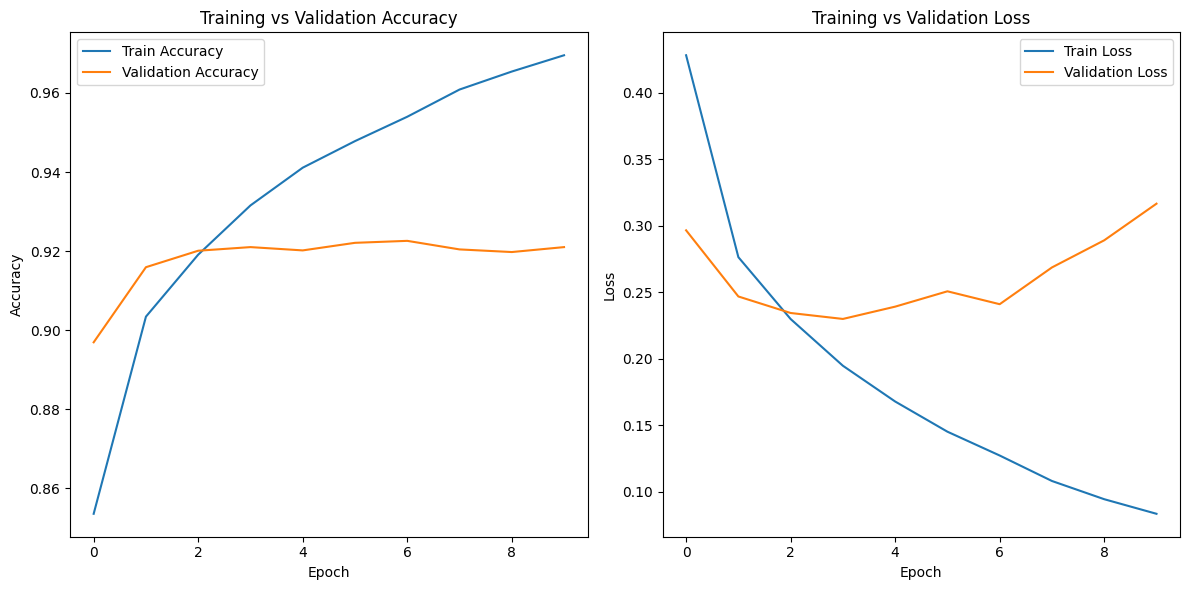

In [50]:
plt.figure(figsize=(12, 6))

# validation accuracy
plt.subplot(1, 2, 1)
plt.plot(cnn_base_history.history['accuracy'],     label='Train Accuracy')
plt.plot(cnn_base_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()

# validation loss
plt.subplot(1, 2, 2)
plt.plot(cnn_base_history.history['loss'],     label='Train Loss')
plt.plot(cnn_base_history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()

plt.show()


### `Hyperparameter tuning for text cnn`

In [51]:
import itertools

# define hyperparameter grid
param_grid = {
    'learning_rate': [0.001, 0.0005],
    'dropout':       [0.3, 0.5],
    'batch_size':    [32, 64],
}

# generate all possible hyperparameter combination
keys         = list(param_grid.keys())
combinations = list(itertools.product(*param_grid.values()))
print(f"Total combinations to try: {len(combinations)}")

# intialize variables to track best validation
# accuracy and training history
best_val_acc = 0
best_params  = {}
best_history = None

# iterate through each combination
for combo in combinations:
    params = dict(zip(keys, combo))
    print(f"\nTrying: {params}")

# define input layer
    inputs = keras.Input(shape=(maxlen,))
    x = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        weights=[embedding_matrix],
        trainable=False  # frozen to prevent overfitting
    )(inputs)

# conv filters using kernel sizes 2, 3 and 4
    x1 = layers.Conv1D(128, 2, activation='relu', padding='same')(x)
    x2 = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x3 = layers.Conv1D(128, 4, activation='relu', padding='same')(x)

# applying max pooling
    x1 = layers.GlobalMaxPooling1D()(x1)
    x2 = layers.GlobalMaxPooling1D()(x2)
    x3 = layers.GlobalMaxPooling1D()(x3)

# pooled features, dropout and dense layer for class probabilities    
    x = layers.Concatenate()([x1, x2, x3])
    x = layers.Dropout(params['dropout'])(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(params['dropout'])(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

# create and display model architecture    
    model = keras.Model(inputs=inputs, outputs=outputs)

# compile model    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=params['learning_rate']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

# define callbacks to stop training if model improvement stops    
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
    ]

# train the model   
    history = model.fit( 
        X_train_pad, y_train,
        batch_size=params['batch_size'],
        epochs=10,
        validation_data=(X_val_pad, y_val),
        callbacks=callbacks,
        verbose=0
    )

# print best validation accuracy   
    val_acc = max(history.history['val_accuracy'])
    print(f"  Best val accuracy: {val_acc:.4f}")

# update parameters to best performing    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params  = params
        best_history = history
        best_cnn     = model

print(f"\nBest Parameters: {best_params}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

y_pred_val = np.argmax(best_cnn.predict(X_val_pad), axis=1)
print("\nTuned CNN Validation")
print(classification_report(y_val, y_pred_val, target_names=target_names))
print(f"Validation Accuracy:  {accuracy_score(y_val, y_pred_val) * 100:.0f}%")
print(f"Validation Precision: {precision_score(y_val, y_pred_val, average='weighted') * 100:.0f}%")
print(f"Validation Recall:    {recall_score(y_val, y_pred_val, average='weighted') * 100:.0f}%")
print(f"Validation F1-score:  {f1_score(y_val, y_pred_val, average='weighted') * 100:.0f}%")

Total combinations to try: 8

Trying: {'learning_rate': 0.001, 'dropout': 0.3, 'batch_size': 32}
  Best val accuracy: 0.9122

Trying: {'learning_rate': 0.001, 'dropout': 0.3, 'batch_size': 64}
  Best val accuracy: 0.9124

Trying: {'learning_rate': 0.001, 'dropout': 0.5, 'batch_size': 32}
  Best val accuracy: 0.9104

Trying: {'learning_rate': 0.001, 'dropout': 0.5, 'batch_size': 64}
  Best val accuracy: 0.9091

Trying: {'learning_rate': 0.0005, 'dropout': 0.3, 'batch_size': 32}
  Best val accuracy: 0.9152

Trying: {'learning_rate': 0.0005, 'dropout': 0.3, 'batch_size': 64}
  Best val accuracy: 0.9120

Trying: {'learning_rate': 0.0005, 'dropout': 0.5, 'batch_size': 32}
  Best val accuracy: 0.9103

Trying: {'learning_rate': 0.0005, 'dropout': 0.5, 'batch_size': 64}
  Best val accuracy: 0.9094

Best Parameters: {'learning_rate': 0.0005, 'dropout': 0.3, 'batch_size': 32}
Best Validation Accuracy: 0.9152
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Tuned CNN Validation
              precision  

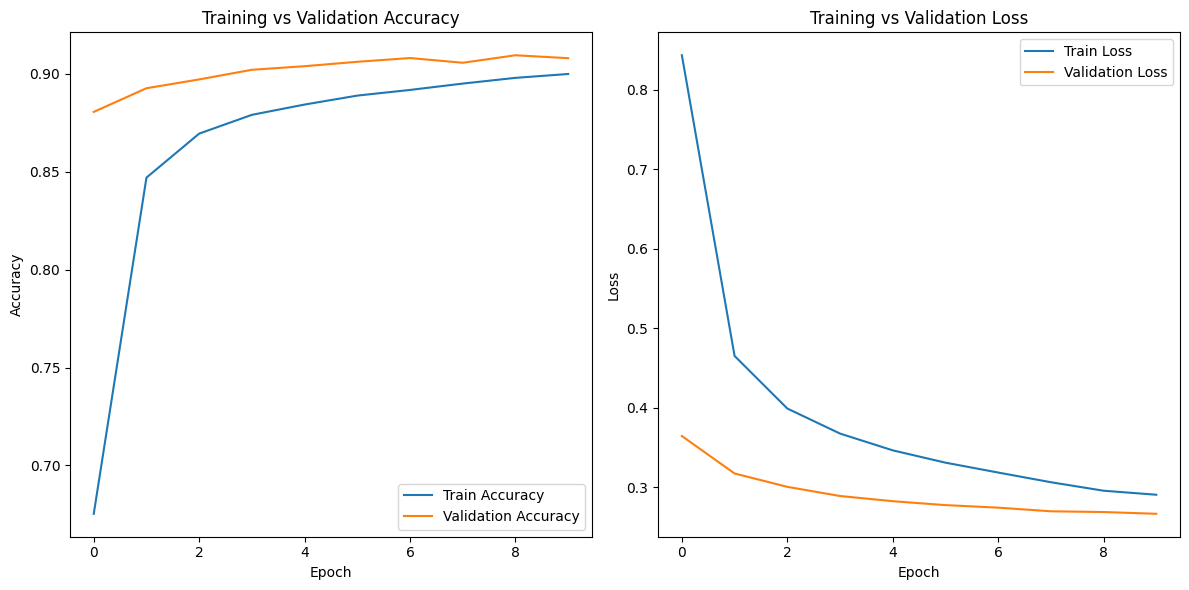

In [52]:
plt.figure(figsize=(12, 6))

# validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()

# validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()

plt.show()


In [53]:
# Evaluate best model on test set
y_pred_cnn_tuned      = np.argmax(best_cnn.predict(X_test_pad), axis=1)

print("\nTuned CNN — Test Results")
print(classification_report(y_test, y_pred_cnn_tuned,
                             target_names=target_names))

238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Tuned CNN — Test Results
              precision    recall  f1-score   support

       World       0.95      0.87      0.91      1900
      Sports       0.95      0.98      0.96      1900
    Business       0.87      0.88      0.87      1900
    Sci/Tech       0.86      0.90      0.88      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



In [54]:
print(f"Final Accuracy for CNN:  {accuracy_score(y_test, y_pred_cnn_tuned) * 100:.0f}%")
print(f"Final Precision for CNN: {precision_score(y_test, y_pred_cnn_tuned, average='weighted') * 100:.0f}%")
print(f"Final Recall for CNN:    {recall_score(y_test, y_pred_cnn_tuned, average='weighted') * 100:.0f}%")
print(f"Final F1-score for CNN:  {f1_score(y_test, y_pred_cnn_tuned, average='weighted') * 100:.0f}%")

Final Accuracy for CNN:  91%
Final Precision for CNN: 91%
Final Recall for CNN:    91%
Final F1-score for CNN:  91%


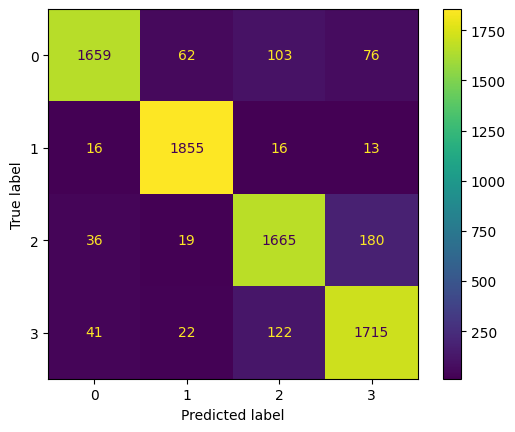

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_cnn_tuned)
ConfusionMatrixDisplay(cm).plot()

In [56]:
cnn_base.save("cnn_model.keras")
model.save("cnn_tuned.keras")

### `Bidirectional Long Short-Term Memory - Base Model`

In [58]:
from tensorflow.keras.layers import (Embedding, Bidirectional,
                                      LSTM, Dense, Dropout,
                                      SpatialDropout1D)
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Base BiLSTM
def build_bilstm_base():
    inputs = tf.keras.Input(shape=(maxlen,))

# create embedding layer with pretrained TF-IDF   
    x = Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        weights=[embedding_matrix_weighted],
        trainable=False # frozen to prevent overfitting
    )(inputs)

# apply hyperparameters for output class probabilities
    x = SpatialDropout1D(0.2)(x)
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Bidirectional(LSTM(64))(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

  
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model
    
# build model  
bilstm_base = build_bilstm_base()
bilstm_base.summary()

# compile model
bilstm_base.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# train model
bilstm_base_history = bilstm_base.fit(
    X_train_pad, y_train,
    batch_size=64,
    epochs=10,
    validation_data=(X_val_pad, y_val),
    verbose=1
)

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)          │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_10 (Embedding)             │ (None, 100, 100)            │       2,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ (None, 100, 100)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 100, 256)            │         234,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 128)                 │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_17 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,407,364 (9.18 MB)

 Trainable params: 407,364 (1.55 MB)

 Non-trainable params: 2,000,000 (7.63 MB)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 161s 94ms/step - accuracy: 0.8537 - loss: 0.4270 - val_accuracy: 0.9151 - val_loss: 0.2508
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 153s 91ms/step - accuracy: 0.9084 - loss: 0.2649 - val_accuracy: 0.9222 - val_loss: 0.2332
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 152s 90ms/step - accuracy: 0.9182 - loss: 0.2345 - val_accuracy: 0.9254 - val_loss: 0.2219
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 160s 95ms/step - accuracy: 0.9228 - loss: 0.2181 - val_accuracy: 0.9258 - val_loss: 0.2187
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 158s 93ms/step - accuracy: 0.9283 - loss: 0.2046 - val_accuracy: 0.9283 - val_loss: 0.2153
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 164s 97ms/step - accuracy: 0.9297 - loss: 0.1981 - val_accuracy: 0.9277 - val_loss: 0.2112
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 161s 95ms/step - accuracy: 0.9335 - loss: 0.1868 - val_accuracy: 0.9284 - val_loss: 0.2104
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 175s 104ms/step - accuracy:

In [59]:
y_pred_bilstm_base_val = np.argmax(bilstm_base.predict(X_val_pad), axis=1)
print("\nBase BiLSTM — Validation Results")
print(classification_report(y_val, y_pred_bilstm_base_val,
                             target_names=target_names))

375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step

Base BiLSTM — Validation Results
              precision    recall  f1-score   support

       World       0.95      0.91      0.93      3000
      Sports       0.97      0.99      0.98      3000
    Business       0.91      0.90      0.90      3000
    Sci/Tech       0.90      0.93      0.91      3000

    accuracy                           0.93     12000
   macro avg       0.93      0.93      0.93     12000
weighted avg       0.93      0.93      0.93     12000



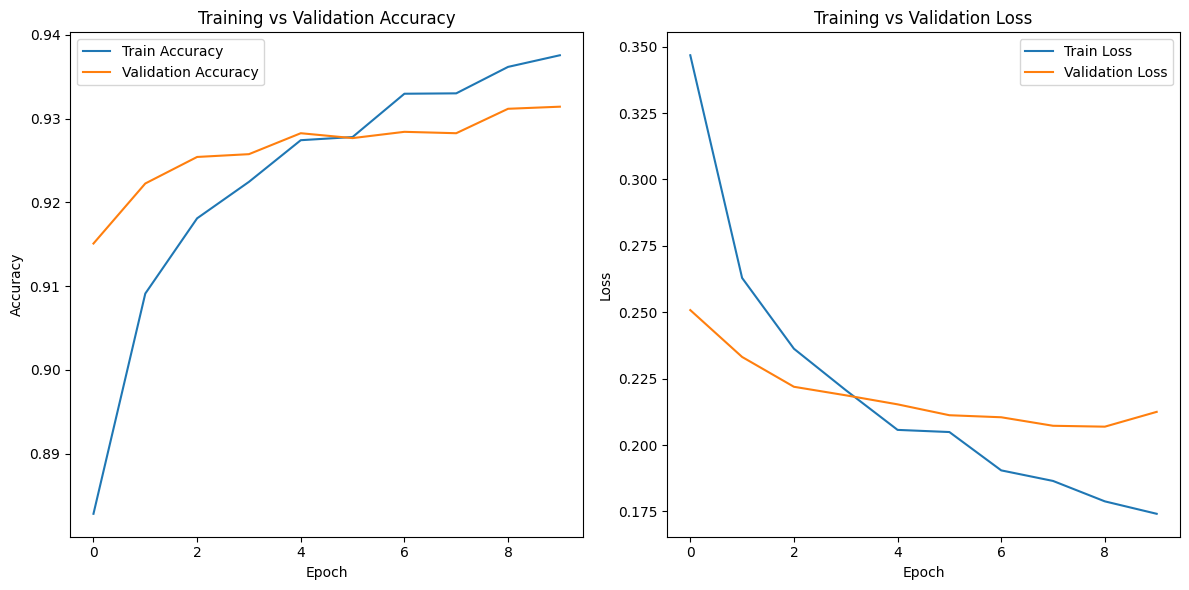

In [60]:
plt.figure(figsize=(12, 6))

# validation accuracy
plt.subplot(1, 2, 1)
plt.plot(bilstm_base_history.history['accuracy'],     label='Train Accuracy')
plt.plot(bilstm_base_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()

# validation loss
plt.subplot(1, 2, 2)
plt.plot(bilstm_base_history.history['loss'],     label='Train Loss')
plt.plot(bilstm_base_history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()

plt.show()


### `Hyperparameter tuning for BILSTM`

In [61]:
import random

# frozen embedding layer using pretrained weighted matrix
def build_bilstm_search(dropout, lr):
    inputs = tf.keras.Input(shape=(maxlen,))
    
    x = Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        weights=[embedding_matrix_weighted],
        trainable=False
    )(inputs)
    
    x = SpatialDropout1D(0.2)(x)
    x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3))(x) 
    x = Bidirectional(LSTM(64, dropout=0.3))(x)                                                 
    x = Dense(64, activation='relu')(x)
    x = Dropout(dropout)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    # building model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# parameters for tuning
param_space = {
    'dropout':       [0.2, 0.3, 0.5],
    'learning_rate': [0.001, 0.0005, 0.0001],
    'batch_size':    [32, 64],
}

# random hyperparameter combination
n_iter = 4  
random.seed(42)
sampled_params = []
seen = set()
while len(sampled_params) < n_iter:
    combo = {k: random.choice(v) for k, v in param_space.items()} # random selection per hyperparameter
    key = str(combo)
    if key not in seen:
        seen.add(key)
        sampled_params.append(combo) # stores unique sampled combinations

print(f"Combinations to try: {n_iter}")
for i, p in enumerate(sampled_params):
    print(f"  {i+1}: {p}")

best_val_acc = 0 # track highest validation
best_params  = {} # stores hyperparameters
best_history = None # stores training history
best_bilstm  = None # stores best-performing BiLSTM
results_log  = [] # stores results

for params in sampled_params:
    print(f"\nTrying: {params}")
    bilstm_tuned_model = build_bilstm_search( # builds BiLSTM model using the sampled hyperparameters
        dropout=params['dropout'],
        lr=params['learning_rate']
    )
    
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=2,   # stops early when val loss stops improving
                      restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
    ]
    
    history = bilstm_tuned_model.fit( # trains the model with chosen batch size and callbacks
        X_train_pad, y_train,
        batch_size=params['batch_size'],
        epochs=10,                                       
        validation_data=(X_val_pad, y_val),
        callbacks=callbacks,
        verbose=1
    )
    
    val_acc = max(history.history['val_accuracy']) # extracts best validation accuracy
    print(f"  Best val accuracy: {val_acc:.4f}")
    
    results_log.append({                          # logs hyperparameters and their achieved accuracy
        'dropout':       params['dropout'],
        'learning_rate': params['learning_rate'],
        'batch_size':    params['batch_size'],
        'val_accuracy':  round(val_acc, 4)
    })
    
    # updates to stored model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params  = params
        best_history = history
        best_bilstm  = bilstm_tuned_model

print("\nRandomized Search Results")
results_df = pd.DataFrame(results_log)
print(results_df.sort_values('val_accuracy', ascending=False).to_string(index=False))
print(f"\nBest Parameters: {best_params}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

# generates class predictions for validation set
y_pred_bilstm_val = np.argmax(best_bilstm.predict(X_val_pad), axis=1)
print("\nTuned BiLSTM — Validation Results")
print(classification_report(y_val, y_pred_bilstm_val, target_names=target_names))

Combinations to try: 4
  1: {'dropout': 0.5, 'learning_rate': 0.001, 'batch_size': 32}
  2: {'dropout': 0.5, 'learning_rate': 0.0005, 'batch_size': 32}
  3: {'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 32}
  4: {'dropout': 0.5, 'learning_rate': 0.0001, 'batch_size': 32}

Trying: {'dropout': 0.5, 'learning_rate': 0.001, 'batch_size': 32}
Epoch 1/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 253s 74ms/step - accuracy: 0.8235 - loss: 0.5113 - val_accuracy: 0.9072 - val_loss: 0.2755 - learning_rate: 0.0010
Epoch 2/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 220s 61ms/step - accuracy: 0.8863 - loss: 0.3436 - val_accuracy: 0.9137 - val_loss: 0.2553 - learning_rate: 0.0010
Epoch 3/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 158s 47ms/step - accuracy: 0.8923 - loss: 0.3174 - val_accuracy: 0.9116 - val_loss: 0.2515 - learning_rate: 0.0010
Epoch 4/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 158s 47ms/step - accuracy: 0.8957 - loss: 0.3037 - val_accuracy: 0.9212 - val_loss: 0.2349 - learning_rate: 0.0010
Epoch 5/10
3375/3375 ━━

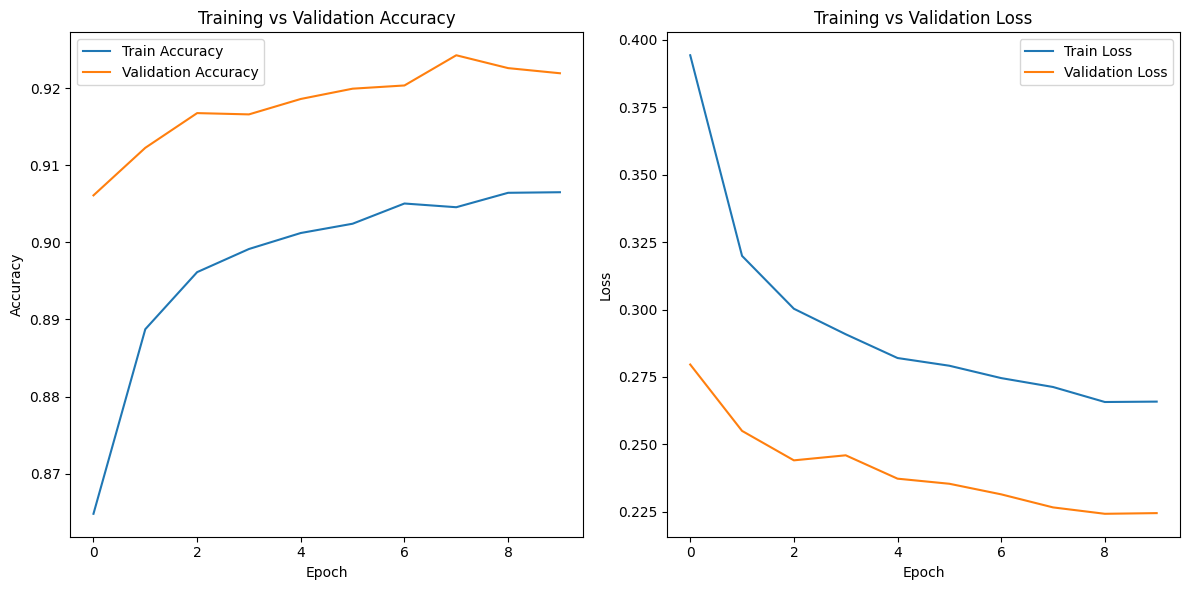

In [62]:
plt.figure(figsize=(12, 6))

# validation accuracy
plt.subplot(1, 2, 1)
plt.plot(best_history.history['accuracy'],     label='Train Accuracy')
plt.plot(best_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()

# validation loss
plt.subplot(1, 2, 2)
plt.plot(best_history.history['loss'],     label='Train Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()

plt.show()


In [64]:
# Final evaluation on test set
y_pred_bilstm_tuned = np.argmax(best_bilstm.predict(X_test_pad), axis=1)

# Convert label_names dict to ordered list
target_names = [label_names[i] for i in sorted(label_names.keys())]

print("\nTuned BiLSTM — Test Results")
print(classification_report(y_test, y_pred_bilstm_tuned,
                             target_names=target_names))
print(f"Final Accuracy for BiLSTM:  {accuracy_score(y_test, y_pred_bilstm_tuned) * 100:.0f}%")
print(f"Final Precision for BiLSTM: {precision_score(y_test, y_pred_bilstm_tuned, average='weighted') * 100:.0f}%")
print(f"Final Recall for BiLSTM:    {recall_score(y_test, y_pred_bilstm_tuned, average='weighted') * 100:.0f}%")
print(f"Final F1-score for BiLSTM:  {f1_score(y_test, y_pred_bilstm_tuned, average='weighted') * 100:.0f}%")

238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step

Tuned BiLSTM — Test Results
              precision    recall  f1-score   support

       World       0.95      0.90      0.93      1900
      Sports       0.96      0.99      0.97      1900
    Business       0.88      0.88      0.88      1900
    Sci/Tech       0.88      0.91      0.89      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600

Final Accuracy for BiLSTM:  92%
Final Precision for BiLSTM: 92%
Final Recall for BiLSTM:    92%
Final F1-score for BiLSTM:  92%


In [65]:
bilstm_base.save("bilstm_base.keras")
bilstm_tuned_model.save("bilstm_tuned.keras")

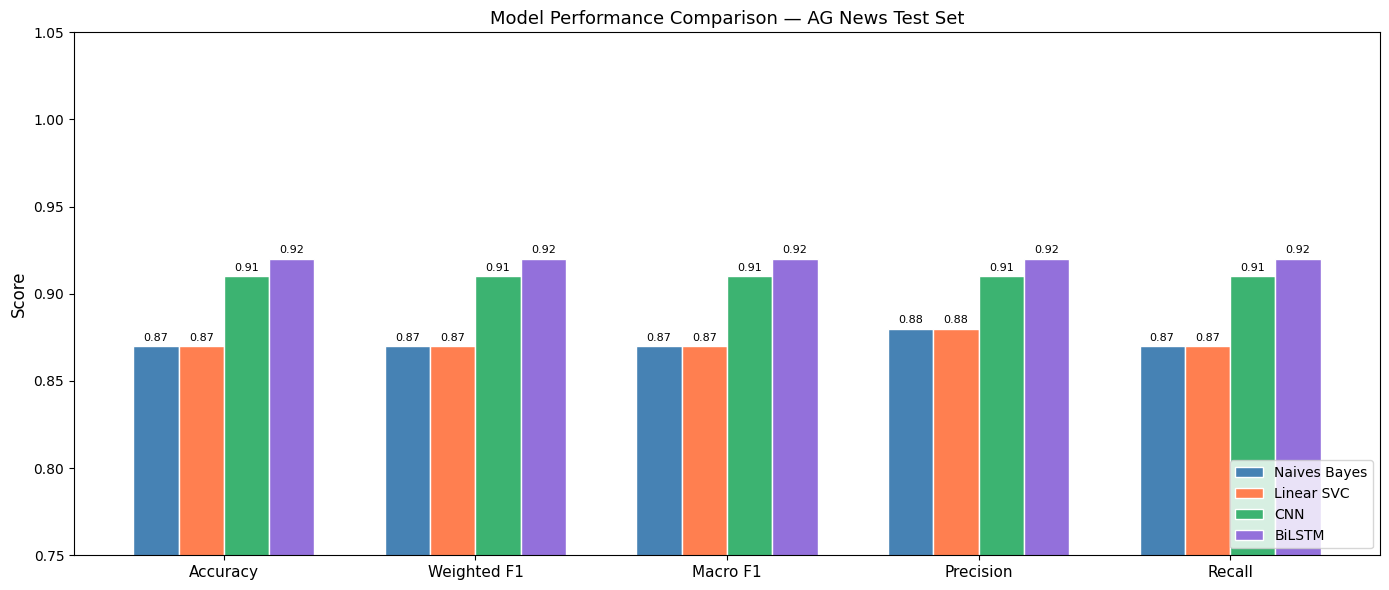

In [66]:
models = ['Naives Bayes', 'Linear SVC', 'CNN', 'BiLSTM']

metrics = {
    'Accuracy':     [0.87, 0.87, 0.91, 0.92],  
    'Weighted F1':  [0.87, 0.87, 0.91, 0.92],
    'Macro F1':     [0.87, 0.87, 0.91, 0.92],
    'Precision':    [0.88, 0.88, 0.91, 0.92],
    'Recall':       [0.87, 0.87, 0.91, 0.92],
}

x         = np.arange(len(metrics))
n_models  = len(models)
width     = 0.18
colors    = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (model, color) in enumerate(zip(models, colors)):
    values = [metrics[m][i] for m in metrics]
    bars   = ax.bar(x + i * width, values, width,
                    label=model, color=color, edgecolor='white')

    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.002,
            f'{height:.2f}',
            ha='center', va='bottom', fontsize=8
        )

ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(metrics.keys(), fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison — AG News Test Set', fontsize=13)
ax.set_ylim(0.75, 1.05)
ax.legend(loc='lower right', fontsize=10)

ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150)
plt.show()

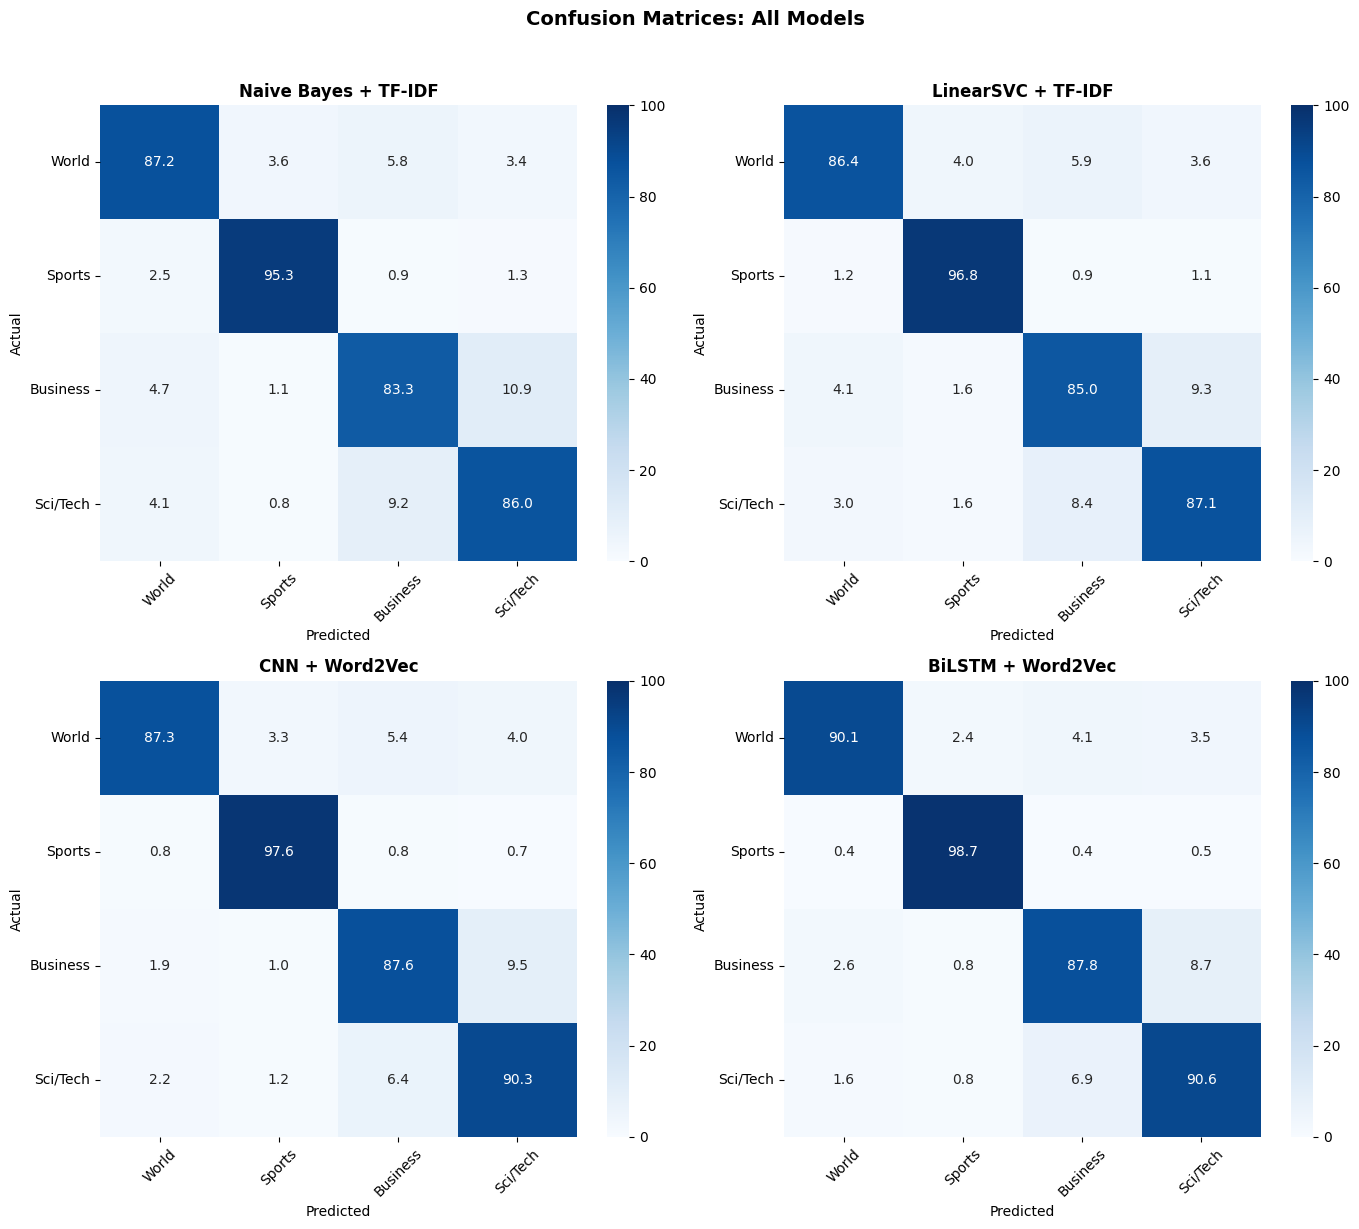

In [68]:
from sklearn.metrics import confusion_matrix

# predictions for all four models 
predictions = {
    'Naive Bayes + TF-IDF':   y_pred_test_nb,
    'LinearSVC + TF-IDF':      y_pred_test_svc,
    'CNN + Word2Vec':           y_pred_cnn_tuned,
    'BiLSTM + Word2Vec':        y_pred_bilstm_tuned
}

label_names = ['World', 'Sports', 'Business', 'Sci/Tech']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, (model_name, y_pred) in zip(axes.flatten(), predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    
    # Normalise to percentages
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.1f',
        cmap='Blues',
        xticklabels=label_names,
        yticklabels=label_names,
        ax=ax,
        cbar=True,
        vmin=0,
        vmax=100
    )
    
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Confusion Matrices: All Models',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices_all_models.png', dpi=150, bbox_inches='tight')
plt.show()